In [1]:
import NCrystal as NC
import numpy as np
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.express as px

In [2]:
wl = np.linspace(0,5,1000)
gauss   = NC.createScatter('Be_sg194_BC_mix-gauss.ncmat')
xs_g    = gauss.crossSectionIsotropic(NC.wl2ekin(wl))
lorentz = NC.createScatter('Be_sg194_BC_mix-lorentz.ncmat')
xs_l    = lorentz.crossSectionIsotropic(NC.wl2ekin(wl))
fresnel = NC.createScatter('Be_sg194_BC_mix-fresnel.ncmat')
xs_f    = fresnel.crossSectionIsotropic(NC.wl2ekin(wl))

NCrystal WARNING: Loading NCMAT data which has @CUSTOM_ section(s). This is OK if intended.
NCrystal WARNING: Loading NCMAT data which has @CUSTOM_ section(s). This is OK if intended.
NCrystal WARNING: Loading NCMAT data which has @CUSTOM_ section(s). This is OK if intended.


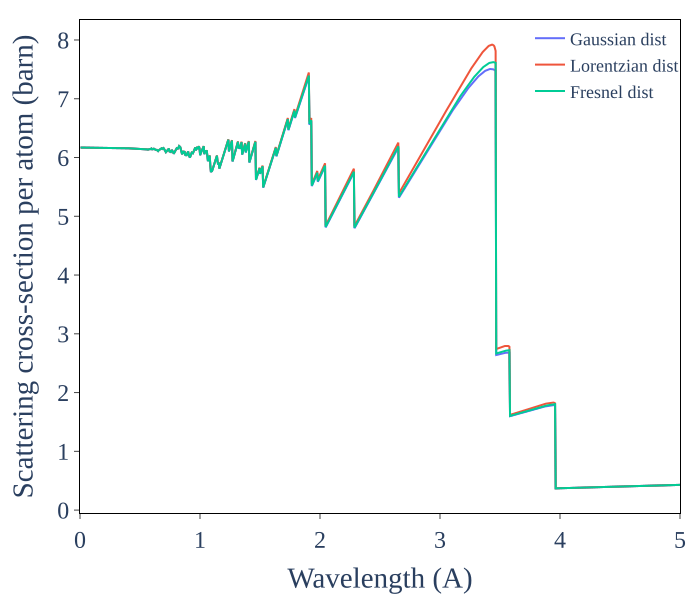

In [3]:
fig = make_subplots(rows = 1, cols = 1)

fig.add_trace(
    go.Scatter(
        x = wl,
        y = xs_g,
        mode = 'lines',
        name = 'Gaussian dist',
    ),
    row = 1, col = 1
)
fig.add_trace(
    go.Scatter(
        x = wl,
        y = xs_l,
        mode = 'lines',
        name = 'Lorentzian dist',
    ),
    row = 1, col = 1
)
fig.add_trace(
    go.Scatter(
        x = wl,
        y = xs_f,
        mode = 'lines',
        name = 'Fresnel dist',
    ),
    row = 1, col = 1
)

fig.update_xaxes(tickfont = dict(size = 24), linecolor = 'black', mirror = True, 
                 ticks = 'outside', exponentformat = 'power', row = 1, col = 1, 
                 #type = 'log', 
                 #range=[0.5, 6],
                 title = 'Wavelength (A)'
                 )
fig.update_yaxes(tickfont = dict(size = 24), linecolor = 'black', mirror = True, 
                 ticks = 'outside', exponentformat = 'power', row = 1, col = 1, 
                 #dtick=1,
                 #type = 'log', 
                 #range=[-1, 10],
                 title = 'Scattering cross-section per atom (barn)')
fig.update_layout(
    paper_bgcolor = 'rgba(0,0,0,0)',
    plot_bgcolor = 'rgba(0,0,0,0)',
    font = dict(family = 'Times new roman', size = 24),
    legend = dict(x = 0.75, y = 1., bordercolor = "Black", borderwidth = 0, font = dict(size = 18)),
    margin = dict(l = 80, r = 20, t = 20, b = 60),
    autosize=False,
    width=700,
    height=600
)
fig.show("svg")